# 07 — Visualization and reports

Everything a run produces lives in its directory (`.soma/runs/<run_id>/`), and
everything in this notebook is a *reader* of those files. Three layers:
readers and aggregation (Rust, `RunView`), overlays on the graph (annotated
mermaid/graphviz), and Plotly figures (`soma.viz`, the
`pip install 'somatize[viz]'` extra).

In [1]:
import json, pathlib

import plotly.io as pio

import soma

# Interactivo (zoom/hover/brushing) en Jupyter y VS Code, con
# fallback PNG donde no hay JS (GitHub incluido).
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].scale = 2      # crisp on retina displays
pio.renderers["png"].width = 950
from soma import Filter, Graph, Study, search


class Scaler(Filter):
    _cache_version = "nb07-scaler-v1"

    def fit(self, x, y=None):
        return {"mean": sum(x) / len(x)}

    def forward(self, x, state):
        return [v - state["mean"] for v in x]


class Model(Filter):
    _cache_version = "nb07-model-v1"

    def fit(self, x, y=None):
        return {"w": 0.5}

    def forward(self, x, state):
        return [v * state["w"] for v in x]


g = Graph()
g.node("scaler", Scaler())
g.node("model", Model())
g.connect("scaler", "model")

with g.track_run("nb07-fit", kind="fit", tags=["demo"]) as run:
    g.fit([1.0, 2.0, 3.0, 4.0])
    for step in range(6):
        run.log("loss", 1.0 / (step + 1), step=step)
        run.log("val_f1", 0.6 + 0.06 * step, step=step)

run.id

'run_20260804T003418_2953'

## Listing and inspecting runs

`soma.runs()` scans `<root>/runs/`, newest first. A `running` run whose
heartbeat has expired is reported as `crashed`. Each `RunView` aggregates the
event log into shapes that are ready to plot.

In [2]:
runs = soma.runs()   # RunList: en notebook se renderiza como tabla
view = runs[0]
runs

run id,kind,state,created,duration,name
run_20260804T003418_2953,fit,completed,2026-08-04 00:34:18,0.0s,nb07-fit


In [3]:
import pandas as pd

print("cache:", view.cache_activity())
pd.DataFrame(view.node_timings())   # per-node spans, ready to tabulate

cache: {'hits': 0, 'misses': 2, 'by_node': {'model': {'hits': 0, 'misses': 1, 'last_tier': None}, 'scaler': {'hits': 0, 'misses': 1, 'last_tier': None}}}


,node_id,started_ts,finished_ts,duration_ms,outcome,cache_tier,error
0,scaler,2026-08-04T00:34:18.980574338Z,2026-08-04T00:34:18.981158640Z,1,completed,None,None
1,model,2026-08-04T00:34:18.982111948Z,2026-08-04T00:34:18.982638040Z,1,completed,None,None


## The annotated architecture

The run's graph with its overlay: per-node duration, cache hits and health
flags, coloured by status. `view.to_svg()` is a self-contained SVG —
`to_mermaid()` and `to_text()` exist too, for docs and external tools.

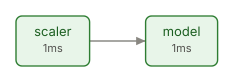

In [4]:
from IPython.display import SVG

SVG(view.to_svg())   # mismo overlay disponible en to_mermaid()

## Figures

Methods installed on `RunView`, returning interactive Plotly figures. They
need the `somatize[viz]` extra.

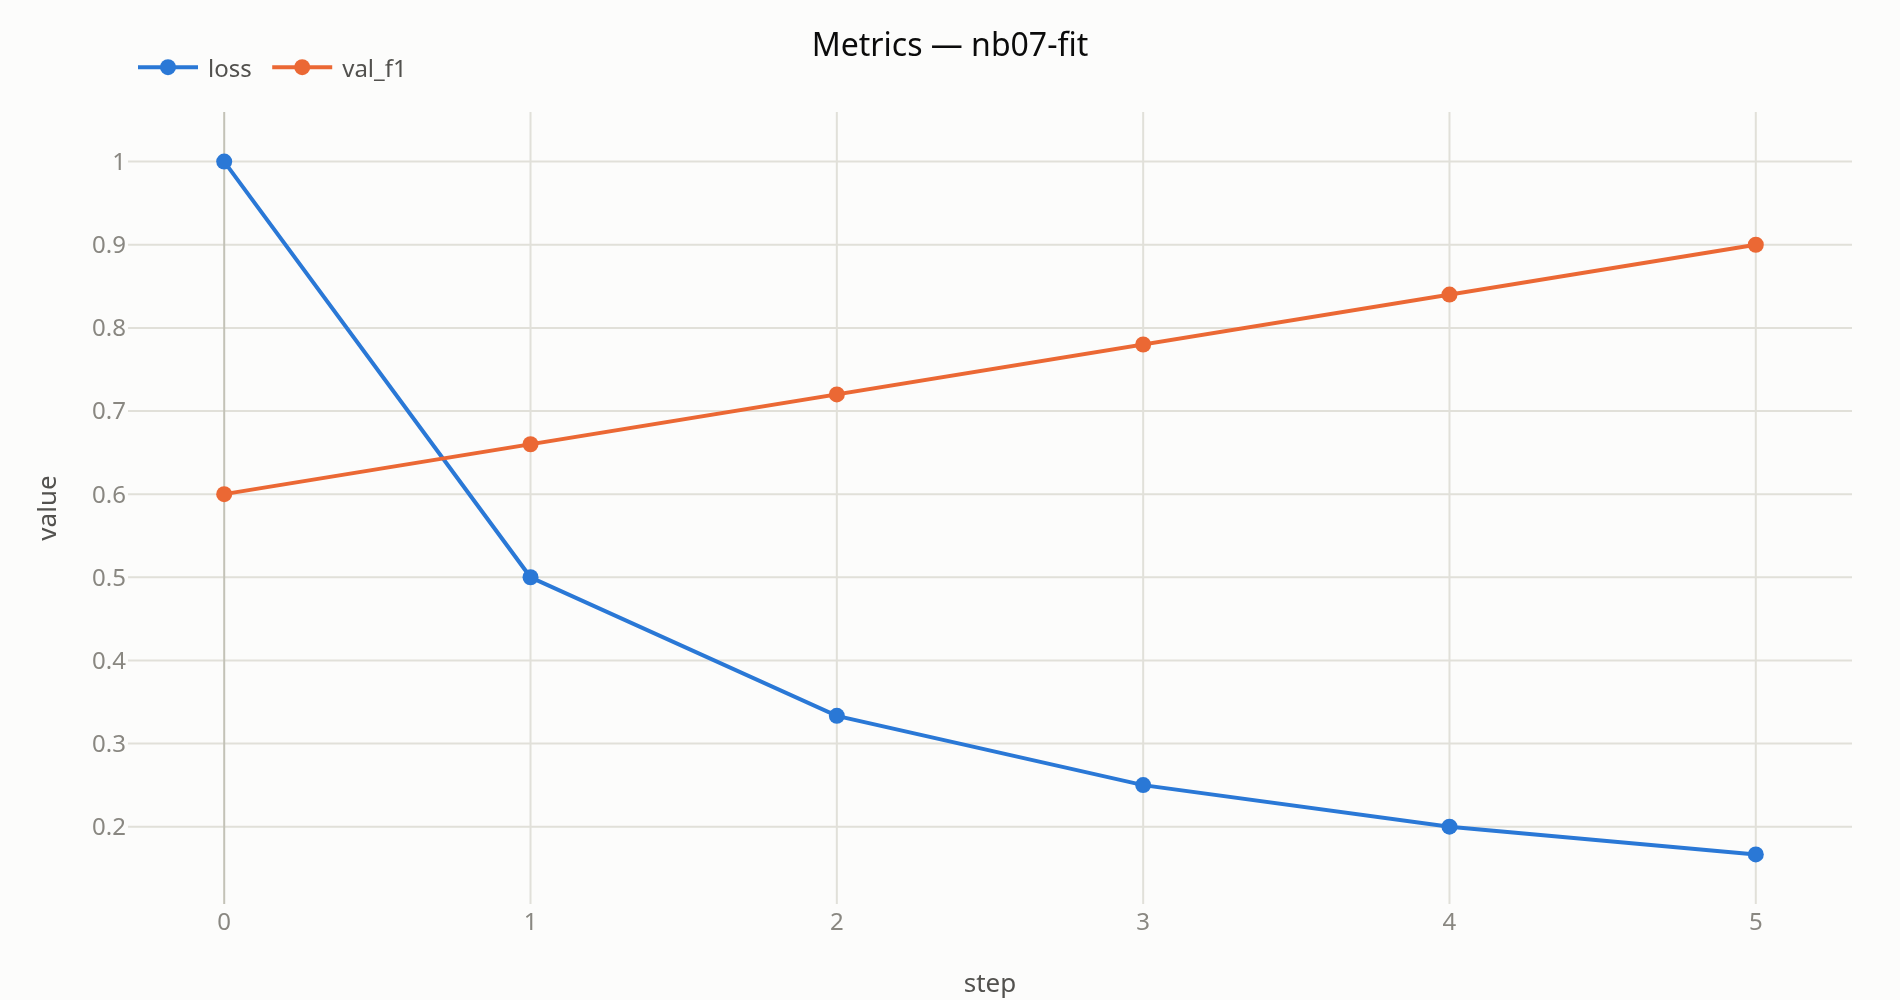

In [5]:
view.plot_metrics()

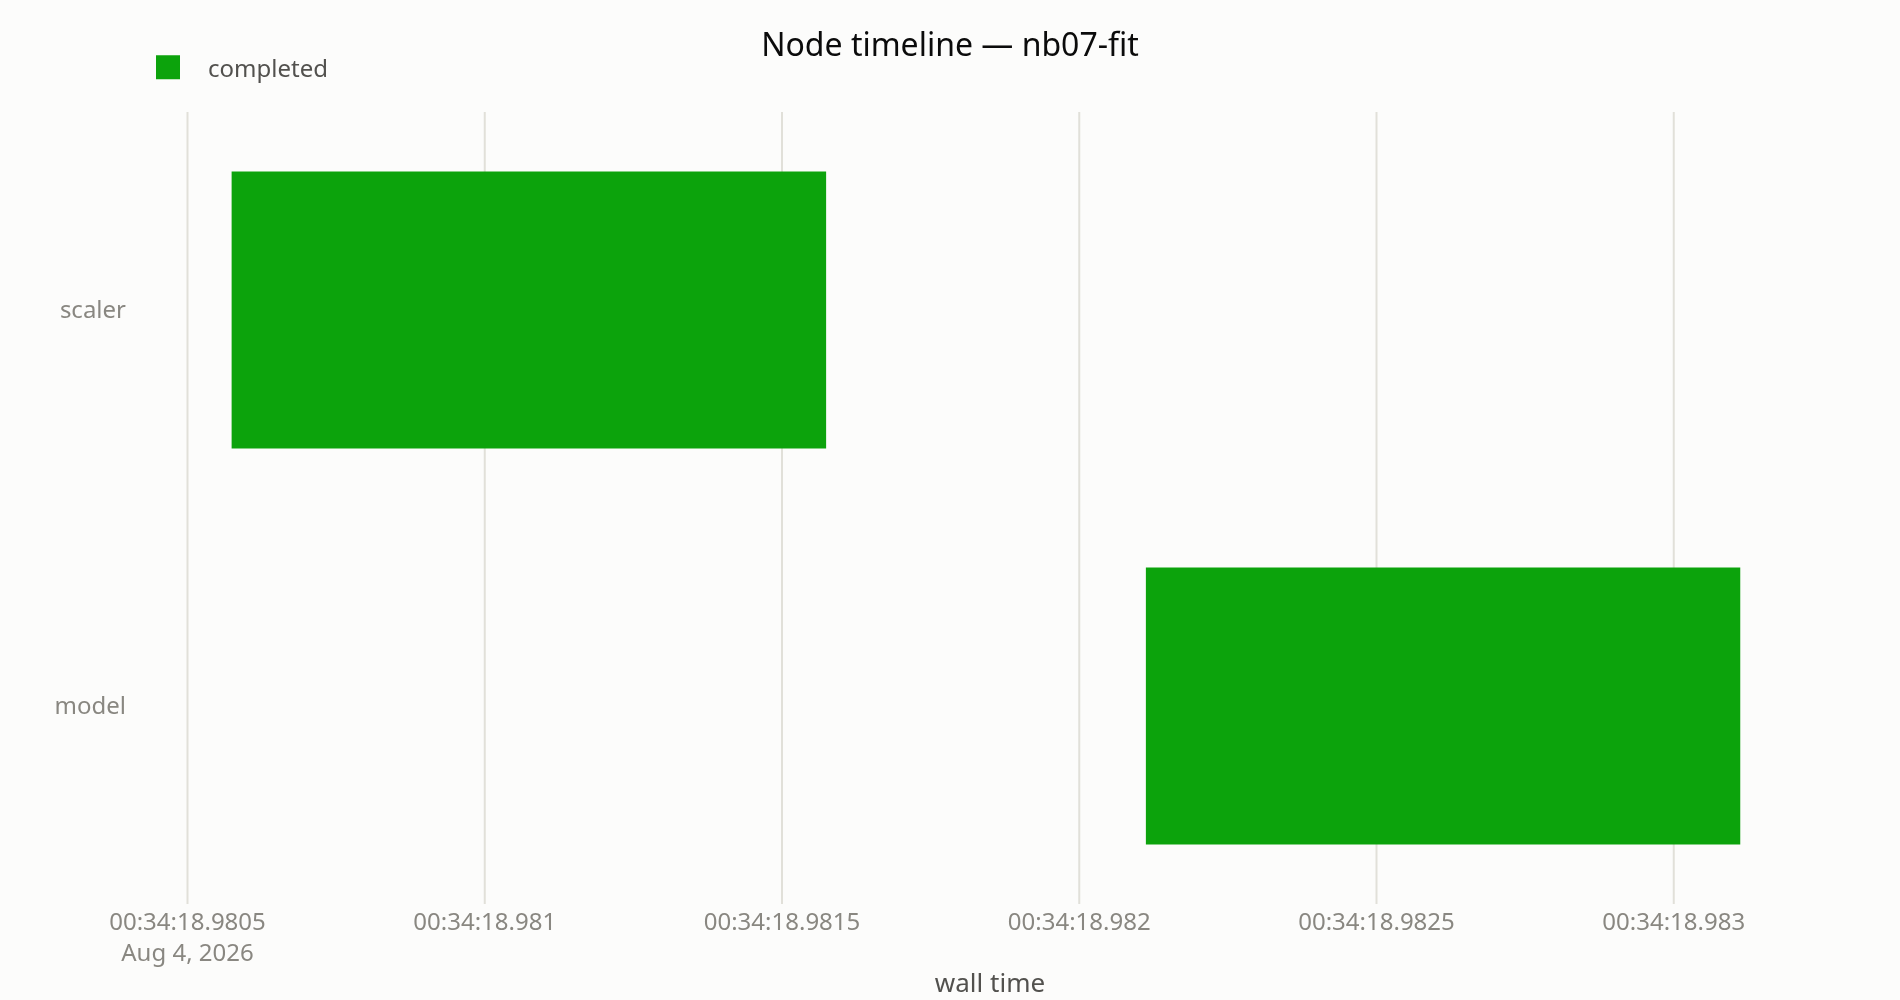

In [6]:
view.plot_gantt()  # where the wall clock went, node by node

## Optuna-style optimization

A `Study` is a run too — its run directory has a `study.json` — and the
figures carry Optuna's names so nobody has to learn new ones. In a terminal,
`study.run(objective, progress=True)` also draws a tqdm bar with the best
value as its suffix (the `somatize[viz]` extra).

In [7]:
def objective(trial):
    for step in range(5):
        f1 = 0.5 + 0.35 * trial["lr"] ** 0.2 * (step + 1) / 5
        if trial.report("f1", f1, step):
            return None
    return None


study = Study(
    "nb07-hpo",
    search_space=[
        {"type": "float", "name": "lr", "low": 1e-4, "high": 1e-1, "scale": "log"},
        {"type": "float", "name": "dropout", "low": 0.0, "high": 0.5},
    ],
    strategy="bayesian",
    n_trials=8,
    objectives=[("f1", "maximize")],
    pruning=("median", 2),
    seed=42,
)
study.run(objective, progress=True)
study.best_trial["id"], study.best_trial["metrics"]

nb07-hpo:   0%|          | 0/8 [00:00<?, ?trial/s]

nb07-hpo: 100%|██████████| 8/8 [00:00<00:00, 219310.01trial/s]

nb07-hpo: 100%|██████████| 8/8 [00:00<00:00, 8520.68trial/s]  

('trial_0006', {'f1': 0.6971705694400159})

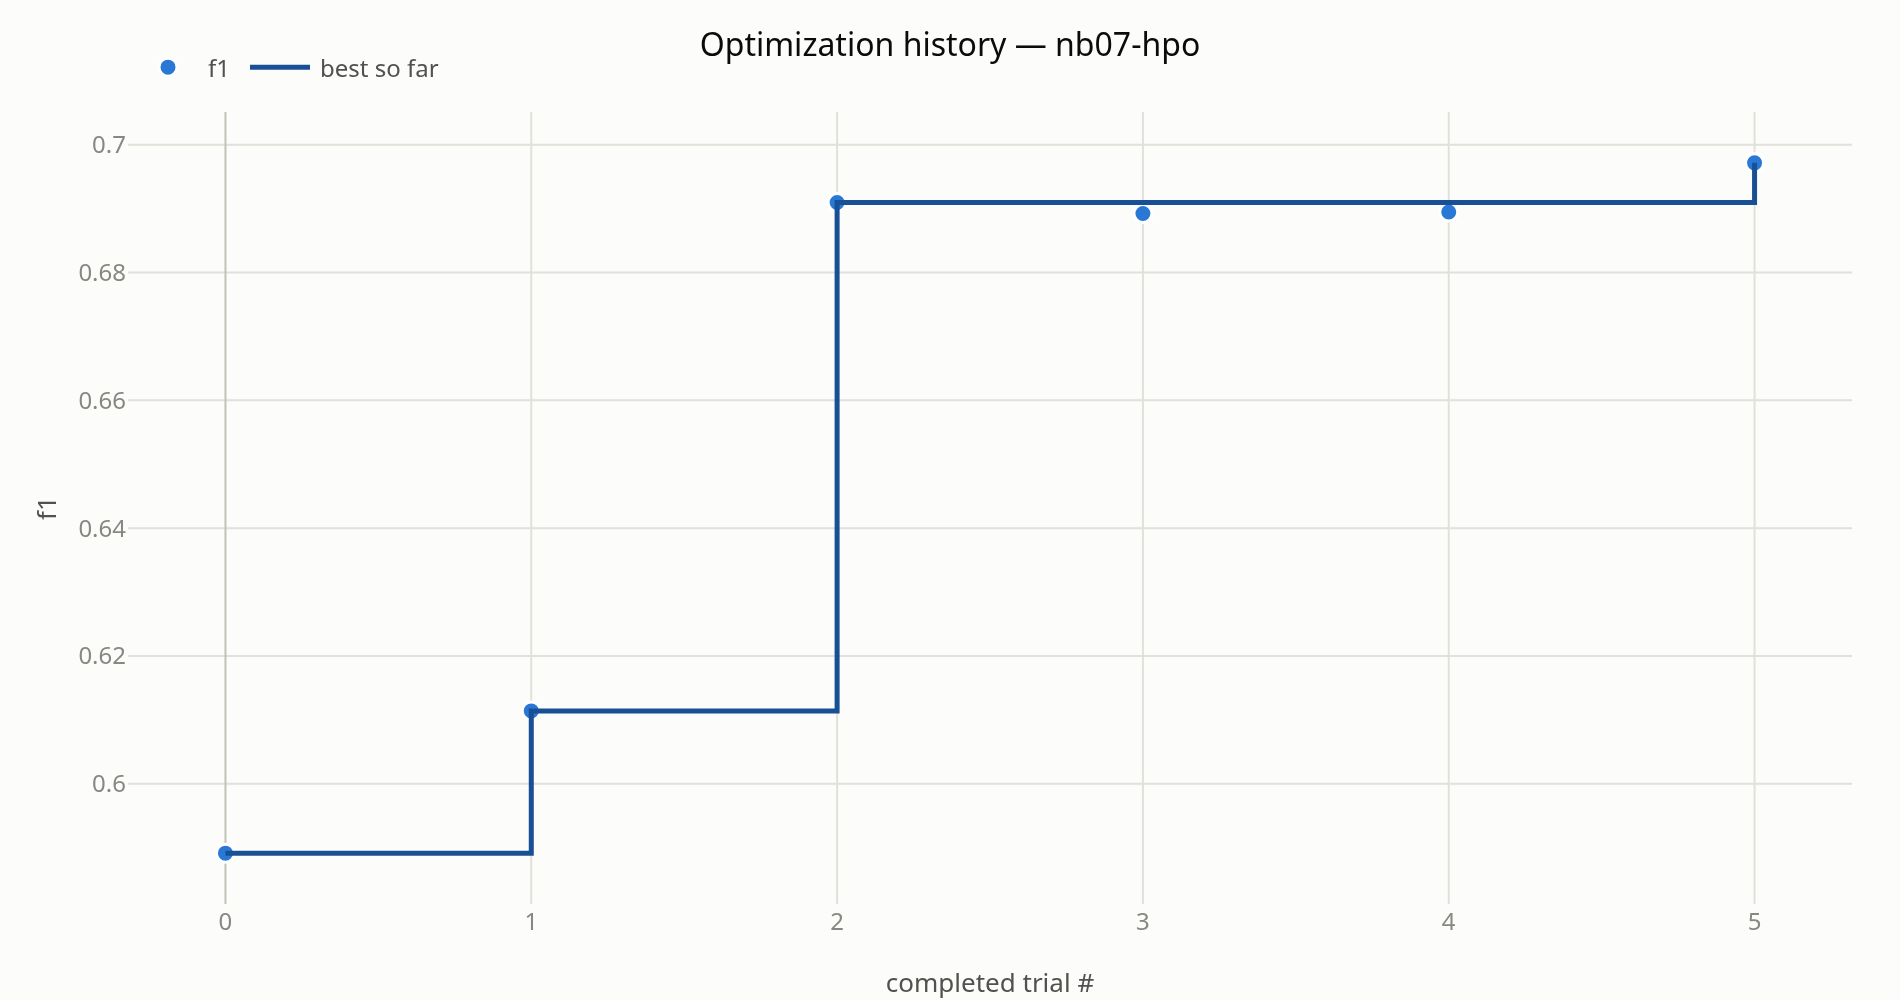

In [8]:
study.plot_optimization_history()

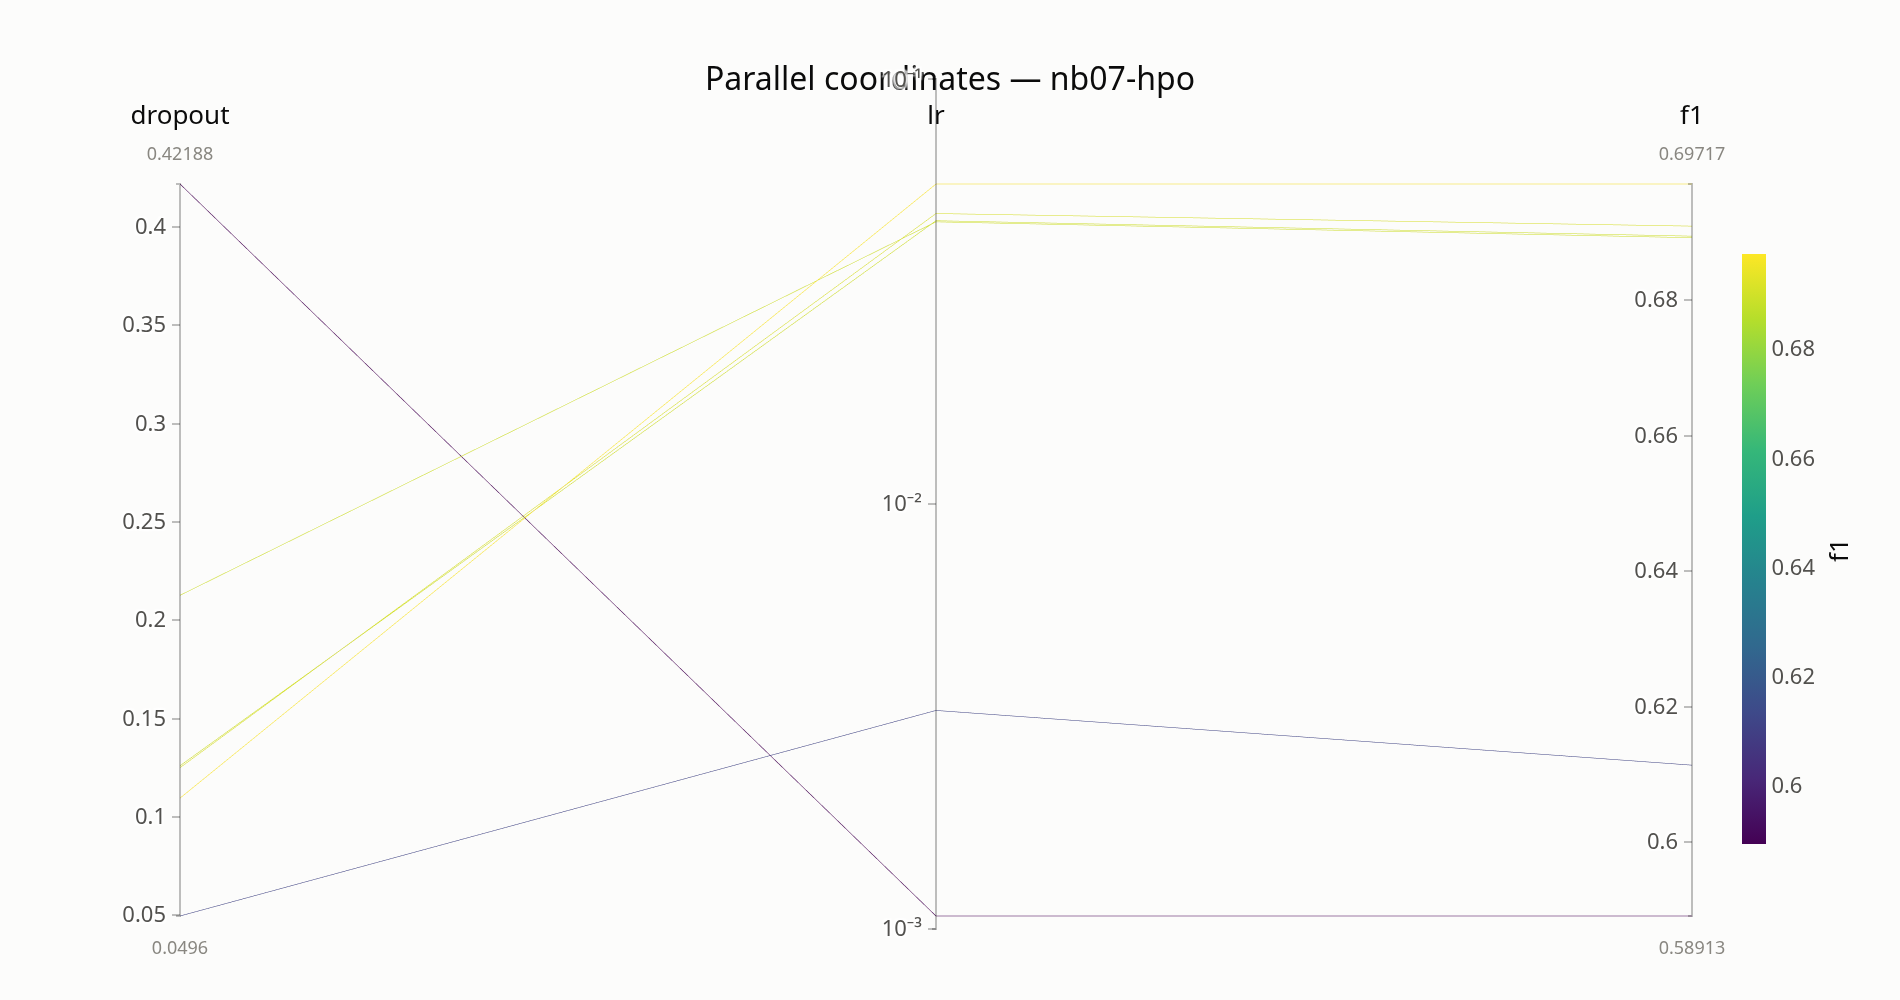

In [9]:
study.plot_parallel_coordinate()

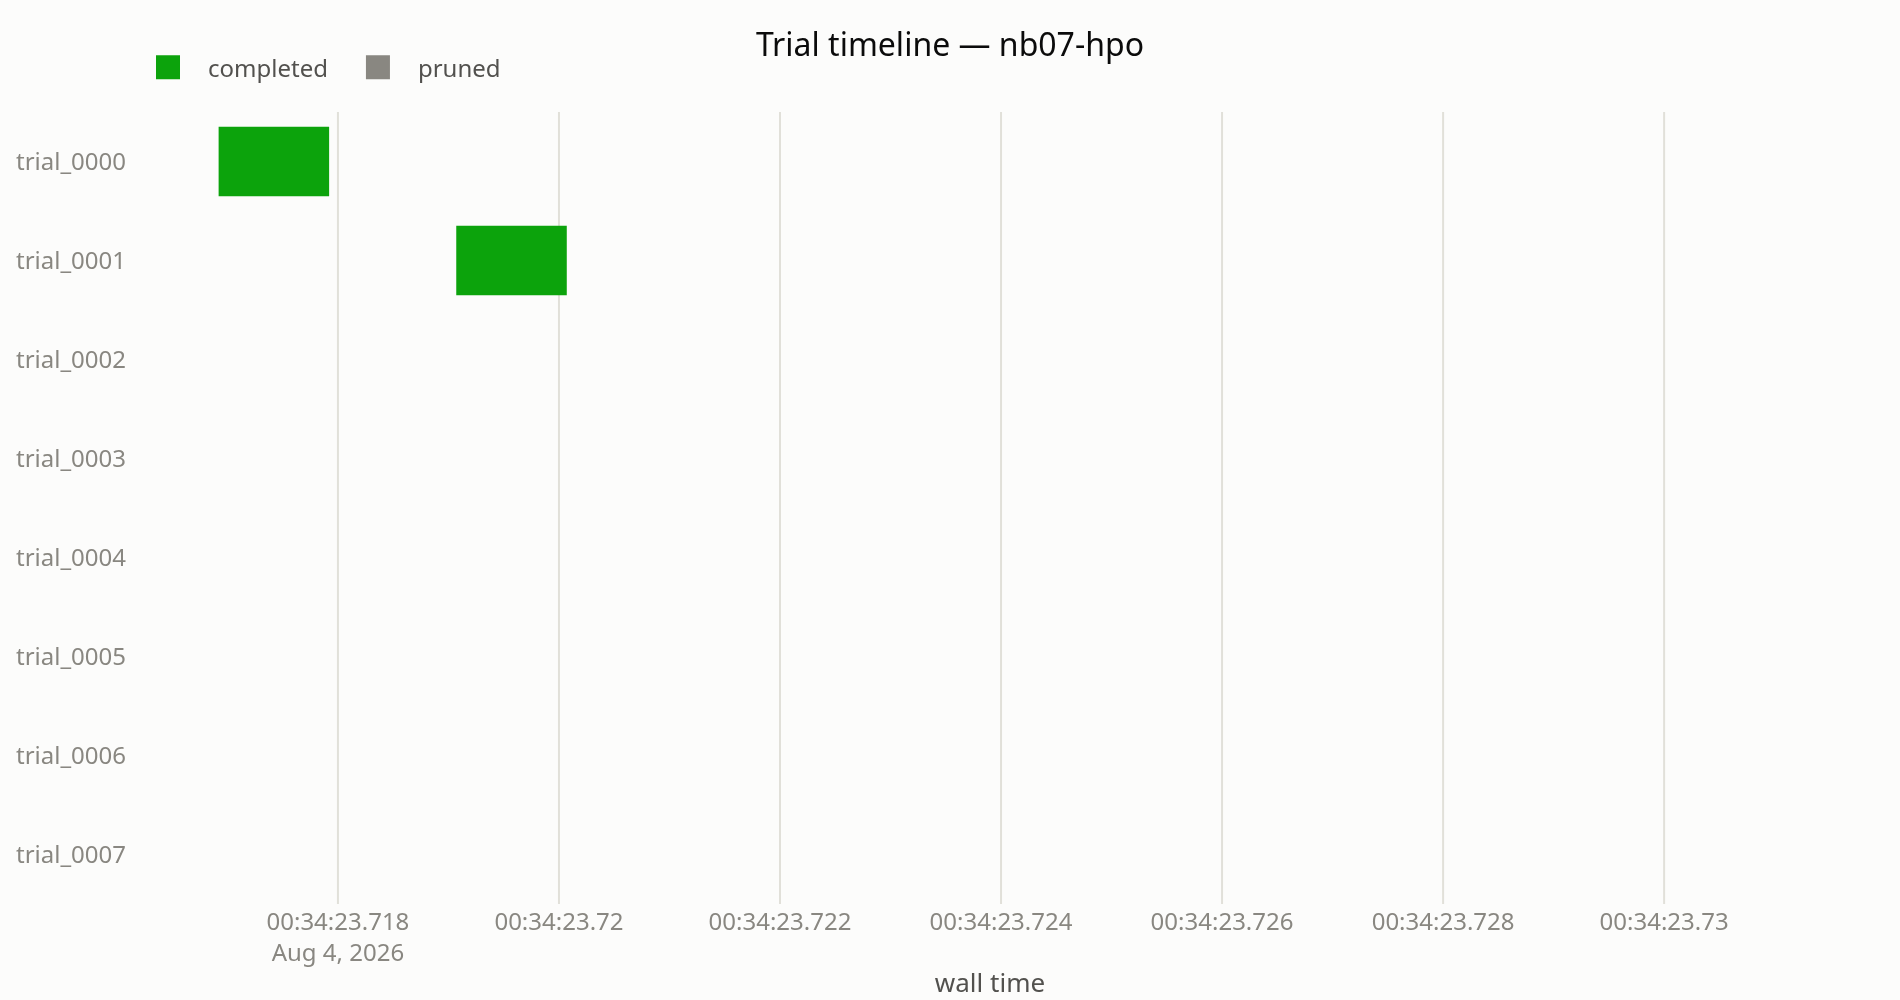

In [10]:
study.plot_timeline()

In [11]:
study.trials_dataframe().head()

,trial_id,state,started_at,finished_at,duration_ms,param_lr,param_dropout,metric_f1
0,trial_0000,completed,2026-08-04 00:34:23.716920285+00:00,2026-08-04 00:34:23.718344859+00:00,1,0.001071,0.421878,0.589134
1,trial_0001,completed,2026-08-04 00:34:23.719070575+00:00,2026-08-04 00:34:23.720303392+00:00,1,0.003266,0.049605,0.611397
2,trial_0002,completed,2026-08-04 00:34:23.721275367+00:00,2026-08-04 00:34:23.722117053+00:00,0,0.048341,0.125046,0.690955
3,trial_0003,pruned,2026-08-04 00:34:23.723029649+00:00,2026-08-04 00:34:23.723545721+00:00,0,0.000259,0.303276,0.540271
4,trial_0004,completed,2026-08-04 00:34:23.724511388+00:00,2026-08-04 00:34:23.725382387+00:00,0,0.046212,0.212712,0.689243


## The HTML report

One self-contained file per run: the annotated DAG, efficiency tiles, curves,
an HPO section with the trial table, and a health section. From the CLI:
`soma report <run_id>` (`--inline` embeds plotly.js so it works with no
network). The embedded `<script id="soma-data-*">` blobs are the contract the
future GUI will read.

In [12]:
html = study.to_html(path="nb07_report.html")
print(f"nb07_report.html: {len(html) / 1024:.0f} KiB")
print("secciones:", [s.split("</h2>")[0] for s in html.split("<h2>")[1:]])

nb07_report.html: 30 KiB
secciones: ['Efficiency', 'Metrics', 'Optimization', 'Trials', 'Health']
